In [3]:
from ultralytics import YOLO
import numpy as np
import cv2
import torch
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch import nn
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import timm
import torch.optim as optim
import os
from datetime import datetime
from torch_geometric.nn import GCNConv

In [64]:
class LizardDataset(Dataset):
    def __init__(self, pt_paths, input_size=512, heatmap_size=512):
        self.paths = pt_paths
        self.input_size = input_size
        self.heatmap_size = heatmap_size

        self.transform = A.Compose([
            A.LongestMaxSize(max_size=input_size),
            A.PadIfNeeded(input_size, input_size, border_mode=cv2.BORDER_CONSTANT),
            A.Affine(
                scale=(0.9, 1.1),
                translate_percent=(0.05, 0.05),
                rotate=(-25, 25),
                p=0.8
            ),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
                A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10)
            ], p=0.7),
            #A.ElasticTransform(alpha=10, sigma=5, p=0.2),
            A.GaussNoise(var_limit=(1,5), p=0.3),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ], keypoint_params=A.KeypointParams(format="xy", remove_invisible=False, label_fields=[]))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        data = torch.load(self.paths[idx])
        img = data["image"].permute(1,2,0).numpy()
        coords = data["tps"].numpy()  # shape (9,2)

        # Clip coords inside original image bounds
        H, W = img.shape[:2]
        coords[:,0] = np.clip(coords[:,0], 0, W-1)
        coords[:,1] = np.clip(coords[:,1], 0, H-1)
        keypoints = [(float(pt[0]), float(pt[1])) for pt in coords]
        
        augmented = self.transform(image=img, keypoints=keypoints)
        
        img_aug = augmented["image"]
        kp_aug = np.array(augmented["keypoints"], dtype=np.float32)
        #print(kp_aug.shape)
        if kp_aug.shape[0] != 9:
            raise ValueError(f"Augmented keypoints shape mismatch: {kp_aug.shape}, expected 9")

        # Clamp and normalize
        kp_aug[:,0] = np.clip(kp_aug[:,0], 0, self.input_size-1)
        kp_aug[:,1] = np.clip(kp_aug[:,1], 0, self.input_size-1)
        coords_norm = kp_aug / self.input_size

        img_tensor = torch.from_numpy(img_aug).permute(2,0,1).float()
        coords_tensor = torch.from_numpy(coords_norm).float()

        return img_tensor, coords_tensor
    

class HRNetGNN(nn.Module):
    def __init__(self, hrnet_backbone, feat_dim=64, gnn_hidden=128, num_layers=2, num_landmarks=9, num_iters=3):
        super().__init__()
        self.num_landmarks = num_landmarks
        self.num_iters = num_iters
        
        self.backbone = timm.create_model(
            "hrnet_w18",
            pretrained=True,
            features_only=True
        )
        
        self.feat_dim = feat_dim
        self.backbone_out_idx = -1
        
        self.node_feat_proj = nn.Linear(self.backbone.feature_info[self.backbone_out_idx]['num_chs'], gnn_hidden)
        
        self.gnn_layers = nn.ModuleList()
        for _ in range(num_layers):
            self. gnn_layers.append(GCNConv(gnn_hidden, gnn_hidden))
            
        self.delta_head = nn.Linear(gnn_hidden, 2)
        
    def sample_features(self, feat_map, coords):
        B, C, H, W = feat_map.shape
        N = coords.shape[1]
        grid = coords.clone()
        
        grid = (grid * 2) - 1
        grid = grid.unsqueeze(2)
        
        sampled = F.grid_sample(feat_map, grid, align_corners=True)
        sampled = sampled.squeeze(-1).permute(0, 2, 1)
        return sampled
    
    def forward(self, x, initial_coords, edge_index):
        coords = initial_coords.clone()
        feat_maps = self.backbone(x)
        feat_map = feat_maps[self.backbone_out_idx]
        
        for _ in range(self.num_iters):
            node_feats = self.sample_features(feat_map, coords)
            node_feats = self.node_feat_proj(node_feats)
            node_feats = F.relu(node_feats)
            B, N, F_dim = node_feats.shape
            node_feats_flat = node_feats.view(B*N, F_dim)
            batch_edge_index = []
            for b in range(B):
                batch_edge_index.append(edge_index + b*N)
            batch_edge_index = torch.cat(batch_edge_index, dim=1)
            
            h = node_feats_flat
            for layer in self.gnn_layers:
                h = layer(h, batch_edge_index)
                h = F.relu(h)
                
            delta = self.delta_head(h)
            delta = delta.view(B, N, 2)
            
            coords = coords + delta
            
        return coords
              

In [117]:
def make_chain_edge_index(num_landmarks=9):
    edges = []
    for i in range(num_landmarks - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])
    edge_index = torch.tensor(edges, dtype=torch.long).t()
    return edge_index

def landmark_loss(pred_coords, gt_coords):
    coord_loss = F.mse_loss(pred_coords, gt_coords)
    pred_dists = (pred_coords[:, 1:] - pred_coords[:, :-1]).norm(dim=-1)
    
    gt_dists = (gt_coords[:, 1:] - gt_coords[:, :-1]).norm(dim=-1)
    dist_loss = F.mse_loss(pred_dists, gt_dists)
    
    return coord_loss + 0.5 * dist_loss
    

def visualize_landmarks(img_tensor, pred_coords, gt_coords=None, save_path="./vis.jpg"):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img * 255).astype('uint8')
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    
    pred_xy = pred_coords.cpu().numpy() * img.shape[1]
    plt.scatter(pred_xy[:,0], pred_xy[:,1], c='r', label='pred', s=30)
    
    if gt_coords is not None:
        gt_xy = gt_coords.cpu().numpy() * img.shape[1]
        plt.scatter(gt_xy[:, 0], gt_xy[:, 1], c='g', label="gt", s=30, marker='x')
        
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()
    
def train(model, train_dataset, val_dataset=None, device='cuda', epochs=10, batch_size=4, lr=1e-4):
    model = model.to(device)
    model.train()
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    edge_index = make_chain_edge_index(num_landmarks=train_dataset[0][1].shape[0]).to(device)
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for imgs, coords in train_loader:
            imgs = imgs.to(device)
            coords = coords.to(device)
            B = imgs.shape[0]
            #initial_coords = coords.clone() + ( torch.rand_like(coords)  * 0.03 )
            mean_shape = torch.tensor([
                [0.3, 0.9], [0.4, 0.8], [0.5, 0.7],
                [0.6, 0.6], [0.7, 0.5], [0.8, 0.4],
                [0.7, 0.3], [0.6, 0.2], [0.5, 0.1],
            ], dtype=torch.float).to(imgs.device)

            initial_coords = mean_shape.unsqueeze(0).repeat(B,1,1)
            
            pred_coords = model(imgs, initial_coords, edge_index)
            loss = landmark_loss(pred_coords, coords)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * imgs.size(0)
            
        epoch_loss /= len(train_dataset)        
        val_loss = None
        if val_dataset is not None:
            model.eval()
            val_loader = DataLoader(val_dataset, batch_size=batch_size)
            val_loss_total = 0.0
            with torch.no_grad():
                for imgs, coords in val_loader:
                    imgs = imgs.to(device)
                    coords = coords.to(device)
                    B = imgs.shape[0]
                    #initial_coords = coords.clone()
                    mean_shape = torch.tensor([
                        [0.3, 0.9], [0.4, 0.8], [0.5, 0.7],
                        [0.6, 0.6], [0.7, 0.5], [0.8, 0.4],
                        [0.7, 0.3], [0.6, 0.2], [0.5, 0.1],
                    ], dtype=torch.float).to(imgs.device)

                    initial_coords = mean_shape.unsqueeze(0).repeat(B,1,1)
                    pred_coords = model(imgs, initial_coords, edge_index)
                    val_loss_total += landmark_loss(pred_coords, coords).item() * imgs.size(0)
            val_loss = val_loss_total / len(val_dataset)
            model.train()
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.6f}" +
             (f", Val Loss: {val_loss:.6f}" if val_loss is not None else ""))
        
        if epoch % 5 == 0:
            visualize_landmarks(imgs[0], pred_coords[0], coords[0])
        
    return model
    

/tmp/ipykernel_2537856/283918544.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(1,5), p=0.3),
Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final_

Epoch 1/80, Train Loss: 0.098185, Val Loss: 0.046297


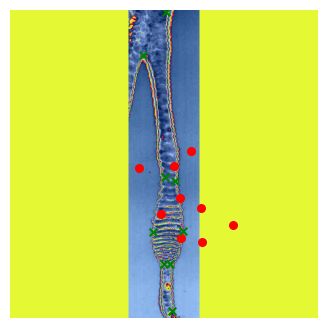

Epoch 2/80, Train Loss: 0.029317, Val Loss: 0.021257
Epoch 3/80, Train Loss: 0.018862, Val Loss: 0.018260
Epoch 4/80, Train Loss: 0.016333, Val Loss: 0.014893
Epoch 5/80, Train Loss: 0.014329, Val Loss: 0.013868
Epoch 6/80, Train Loss: 0.012569, Val Loss: 0.012132


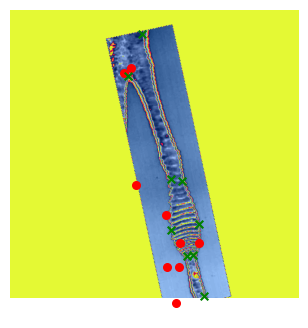

Epoch 7/80, Train Loss: 0.013748, Val Loss: 0.015872
Epoch 8/80, Train Loss: 0.016618, Val Loss: 0.014423
Epoch 9/80, Train Loss: 0.012638, Val Loss: 0.011360
Epoch 10/80, Train Loss: 0.010554, Val Loss: 0.009839
Epoch 11/80, Train Loss: 0.009116, Val Loss: 0.008805


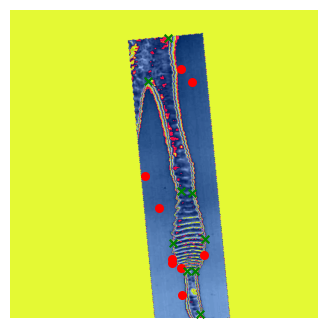

Epoch 12/80, Train Loss: 0.008587, Val Loss: 0.009782
Epoch 13/80, Train Loss: 0.007711, Val Loss: 0.008066
Epoch 14/80, Train Loss: 0.006811, Val Loss: 0.006941
Epoch 15/80, Train Loss: 0.006228, Val Loss: 0.006844
Epoch 16/80, Train Loss: 0.005680, Val Loss: 0.005840


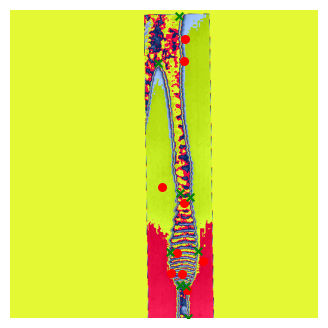

Epoch 17/80, Train Loss: 0.005689, Val Loss: 0.006218
Epoch 18/80, Train Loss: 0.006411, Val Loss: 0.007907
Epoch 19/80, Train Loss: 0.005817, Val Loss: 0.006126
Epoch 20/80, Train Loss: 0.005116, Val Loss: 0.005496
Epoch 21/80, Train Loss: 0.004778, Val Loss: 0.004136


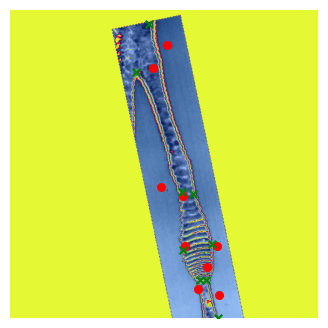

Epoch 22/80, Train Loss: 0.003306, Val Loss: 0.004082
Epoch 23/80, Train Loss: 0.005054, Val Loss: 0.004418
Epoch 24/80, Train Loss: 0.004288, Val Loss: 0.004312
Epoch 25/80, Train Loss: 0.003230, Val Loss: 0.003080
Epoch 26/80, Train Loss: 0.004368, Val Loss: 0.004895


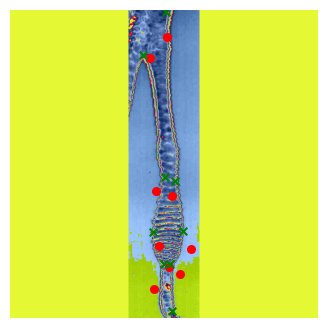

Epoch 27/80, Train Loss: 0.004078, Val Loss: 0.003069
Epoch 28/80, Train Loss: 0.002917, Val Loss: 0.003483
Epoch 29/80, Train Loss: 0.002504, Val Loss: 0.002915
Epoch 30/80, Train Loss: 0.002426, Val Loss: 0.003281
Epoch 31/80, Train Loss: 0.002202, Val Loss: 0.002631


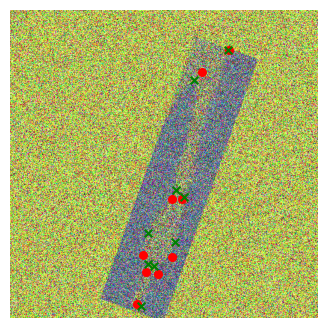

Epoch 32/80, Train Loss: 0.001699, Val Loss: 0.002462
Epoch 33/80, Train Loss: 0.001957, Val Loss: 0.002490
Epoch 34/80, Train Loss: 0.002019, Val Loss: 0.002976
Epoch 35/80, Train Loss: 0.002397, Val Loss: 0.003170
Epoch 36/80, Train Loss: 0.003705, Val Loss: 0.003204


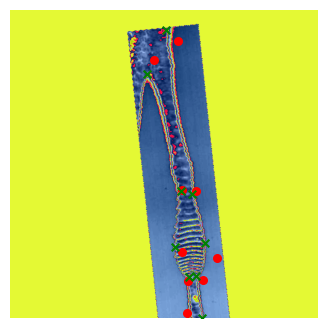

Epoch 37/80, Train Loss: 0.003801, Val Loss: 0.004366
Epoch 38/80, Train Loss: 0.003185, Val Loss: 0.004252
Epoch 39/80, Train Loss: 0.004466, Val Loss: 0.004118
Epoch 40/80, Train Loss: 0.004652, Val Loss: 0.003991
Epoch 41/80, Train Loss: 0.002811, Val Loss: 0.002606


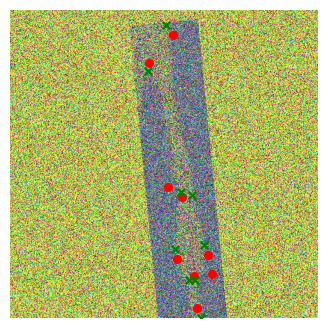

Epoch 42/80, Train Loss: 0.002006, Val Loss: 0.002192
Epoch 43/80, Train Loss: 0.001902, Val Loss: 0.003786
Epoch 44/80, Train Loss: 0.001999, Val Loss: 0.001889
Epoch 45/80, Train Loss: 0.001861, Val Loss: 0.002843
Epoch 46/80, Train Loss: 0.001867, Val Loss: 0.002358


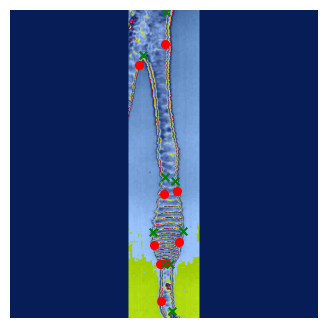

Epoch 47/80, Train Loss: 0.001665, Val Loss: 0.002884
Epoch 48/80, Train Loss: 0.002197, Val Loss: 0.002617
Epoch 49/80, Train Loss: 0.001747, Val Loss: 0.002037
Epoch 50/80, Train Loss: 0.001684, Val Loss: 0.002329
Epoch 51/80, Train Loss: 0.001414, Val Loss: 0.001854


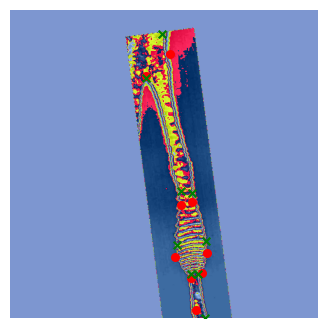

Epoch 52/80, Train Loss: 0.001775, Val Loss: 0.001716
Epoch 53/80, Train Loss: 0.001319, Val Loss: 0.001542
Epoch 54/80, Train Loss: 0.001333, Val Loss: 0.001873
Epoch 55/80, Train Loss: 0.001663, Val Loss: 0.001719
Epoch 56/80, Train Loss: 0.001250, Val Loss: 0.001586


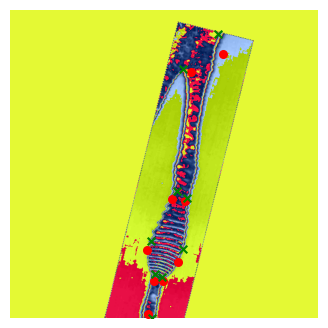

Epoch 57/80, Train Loss: 0.001065, Val Loss: 0.001180
Epoch 58/80, Train Loss: 0.000977, Val Loss: 0.001436
Epoch 59/80, Train Loss: 0.000979, Val Loss: 0.001350
Epoch 60/80, Train Loss: 0.000999, Val Loss: 0.001368
Epoch 61/80, Train Loss: 0.000997, Val Loss: 0.001181


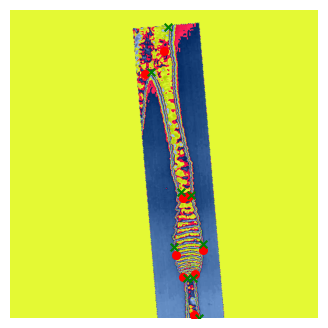

Epoch 62/80, Train Loss: 0.001104, Val Loss: 0.001450
Epoch 63/80, Train Loss: 0.000981, Val Loss: 0.001254
Epoch 64/80, Train Loss: 0.000880, Val Loss: 0.001128
Epoch 65/80, Train Loss: 0.000886, Val Loss: 0.001017
Epoch 66/80, Train Loss: 0.000838, Val Loss: 0.001127


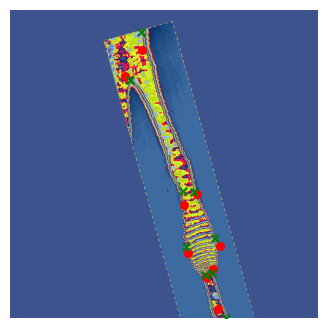

Epoch 67/80, Train Loss: 0.001043, Val Loss: 0.001436
Epoch 68/80, Train Loss: 0.001078, Val Loss: 0.001608
Epoch 69/80, Train Loss: 0.000981, Val Loss: 0.001585
Epoch 70/80, Train Loss: 0.000958, Val Loss: 0.001134
Epoch 71/80, Train Loss: 0.000892, Val Loss: 0.001021


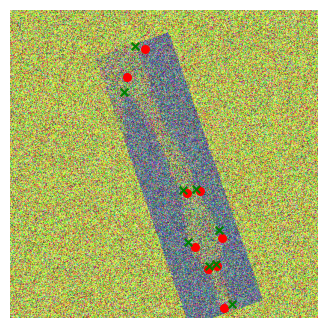

Epoch 72/80, Train Loss: 0.000890, Val Loss: 0.001029
Epoch 73/80, Train Loss: 0.001152, Val Loss: 0.001613
Epoch 74/80, Train Loss: 0.001250, Val Loss: 0.001688
Epoch 75/80, Train Loss: 0.001194, Val Loss: 0.001393
Epoch 76/80, Train Loss: 0.001355, Val Loss: 0.001448


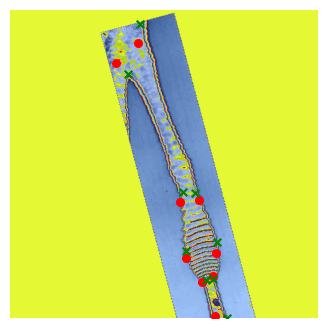

Epoch 77/80, Train Loss: 0.001416, Val Loss: 0.001684
Epoch 78/80, Train Loss: 0.001195, Val Loss: 0.002141
Epoch 79/80, Train Loss: 0.001308, Val Loss: 0.001722
Epoch 80/80, Train Loss: 0.001166, Val Loss: 0.001079


In [119]:
DATA_PATH = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/hrnet/heatmaps/"
pt_paths = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".pt")]

dataset = LizardDataset(pt_paths, input_size=512)
train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

model = HRNetGNN(hrnet_backbone="hrnet_w18", feat_dim=1024, gnn_hidden=128,
                num_layers=3, num_landmarks=9, num_iters=6)

trained_model = train(model, train_dataset, val_dataset=val_dataset,
                     device='cuda' if torch.cuda.is_available() else 'cpu',
                     epochs=80, batch_size=32, lr=1e-4)

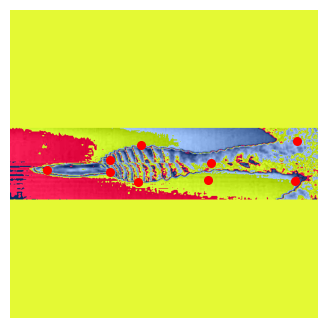

In [136]:
mean_shape = torch.tensor([
    [0.3, 0.9], [0.4, 0.8], [0.5, 0.7],
    [0.6, 0.6], [0.7, 0.5], [0.8, 0.4],
    [0.7, 0.3], [0.6, 0.2], [0.5, 0.1],
])

initial_coords = mean_shape.unsqueeze(0).to('cuda')
edge_index = make_chain_edge_index(num_landmarks=9).to('cuda')
transform = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

trained_model.eval()
p = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/raw_data/test_data/"
img = cv2.imread(f"{p}1489_finger.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

aug = transform(image=img_rgb, keypoints=[])
img_input = torch.from_numpy(aug['image']).permute(2,0,1).unsqueeze(0).float()
img_input = img_input.to('cuda')

with torch.no_grad():
    pred_coords = trained_model(img_input, initial_coords, edge_index)
    pred_coords = pred_coords[0]

visualize_landmarks(img_input[0], pred_coords, gt_coords=None)
    
